In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from sqlalchemy import text

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from dotenv import load_dotenv
load_dotenv(project_root / ".env")
from etl.common.db.postgres import get_engine

engine = get_engine()

In [2]:
with engine.connect() as conn:
    df = pd.read_sql(
        text("""
            SELECT date_day, eth_close_usd
            FROM analytics.market_variables_history
            WHERE date_day BETWEEN '2021-05-01' AND CURRENT_DATE
              AND eth_close_usd IS NOT NULL
            ORDER BY date_day
        """),
        conn,
    )

df["date_day"] = pd.to_datetime(df["date_day"])
print(f"Rows: {len(df)}  |  {df['date_day'].min().date()} → {df['date_day'].max().date()}")

Rows: 1823  |  2021-05-01 → 2026-04-27


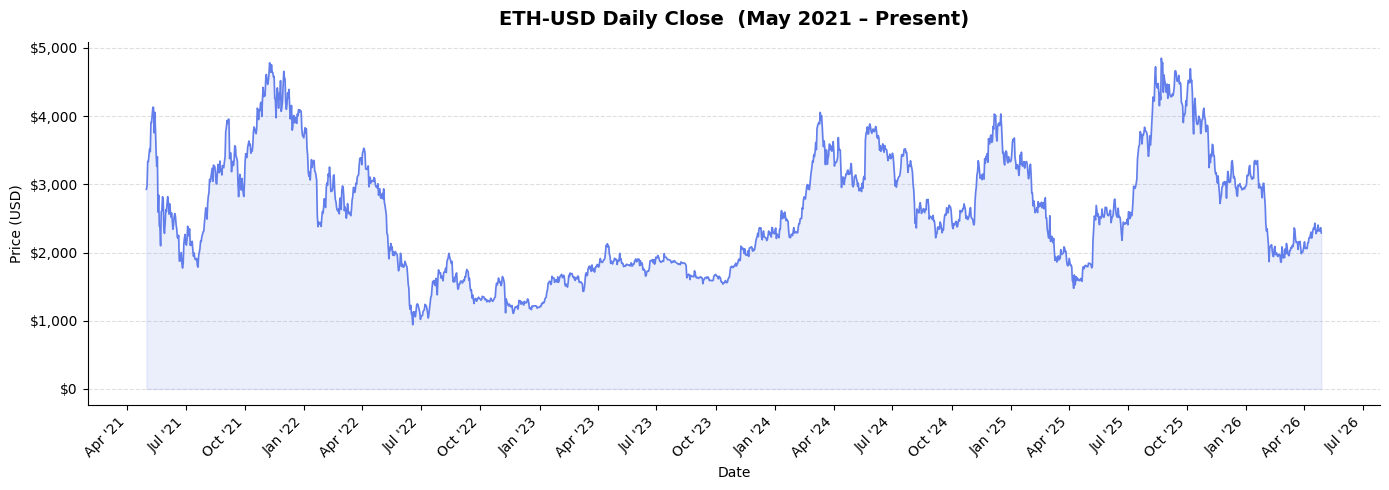

In [3]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df["date_day"], df["eth_close_usd"], color="#627EEA", linewidth=1.2)
ax.fill_between(df["date_day"], df["eth_close_usd"], alpha=0.12, color="#627EEA")

ax.set_title("ETH-USD Daily Close  (May 2021 – Present)", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.xticks(rotation=45, ha="right")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()